In [84]:
!git clone https://github.com/gettokeroro/DADS5001_MINI_PROJECT.git
%cd DADS5001_MINI_PROJECT
!ls

Cloning into 'DADS5001_MINI_PROJECT'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 78 (delta 23), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 12.86 MiB | 5.85 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/DADS5001_MINI_PROJECT/DADS5001_MINI_PROJECT/DADS5001_MINI_PROJECT/DADS5001_MINI_PROJECT
dataset				KA_Job_Application_Analysis.ipynb  README.md
Job_Application_Analysis.ipynb	notebooks


In [85]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load (relative path within the dataset)
file_path = "postings.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "arshkon/linkedin-job-postings",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

display(df.head())

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [87]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import os

if os.path.exists("/kaggle/input/linkedin-job-postings/"):
    DATASET_PATH = "/kaggle/input/linkedin-job-postings/"
else:
    DATASET_PATH = "dataset/"   # dataset ที่อยู่ใน GitHub repo

# Dictionary to map file names to their respective subdirectories
file_subdirs = {
    "companies.csv": "companies/",
    "company_industries.csv": "companies/",
    "employee_counts.csv": "companies/",
    "industries.csv": "mappings/",
    "skills.csv": "mappings/",
    "job_skills.csv": "jobs/",
    "job_industries.csv": "jobs/"
}

# List of additional files to load (keys of the dictionary)
additional_files = list(file_subdirs.keys())

# Load each file into a separate DataFrame
for file_name in additional_files:
    print(f"\nLoading {file_name}...")
    try:
        # Create a meaningful DataFrame name (e.g., df_companies)
        df_name = file_name.replace('.csv', '')
        # Construct the full path using the subdirectory information
        full_file_path = os.path.join(DATASET_PATH, file_subdirs[file_name], file_name)
        globals()[f'df_{df_name}'] = pd.read_csv(full_file_path)
        print(f"First 5 records of df_{df_name}:")
        display(globals()[f'df_{df_name}'].head())
    except Exception as e:
        print(f"Error loading {file_name}: {e}")

# You can now access these DataFrames using names like df_companies, df_industries, etc.


Loading companies.csv...
First 5 records of df_companies:


,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,Accenture is a leading global professional ser...,7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture



Loading company_industries.csv...
First 5 records of df_company_industries:


,company_id,industry
0,391906,Book and Periodical Publishing
1,22292832,Construction
2,20300,Banking
3,3570660,Book and Periodical Publishing
4,878353,Staffing and Recruiting



Loading employee_counts.csv...
First 5 records of df_employee_counts:


...

,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution



Loading job_skills.csv...
First 5 records of df_job_skills:


,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN



Loading job_industries.csv...
First 5 records of df_job_industries:


,job_id,industry_id
0,3884428798,82
1,3887473071,48
2,3887465684,41
3,3887467939,82
4,3887467939,80


# Prepare Data  & Cleansing

**1. Remove rows with NaN `company_id`**

**2. Convert `original_listed_time` and `expiry` to date format**


**3. Replace NaN with 0 in `remote_allowed`**


**4. Merge `df_job_industries` with `df_industries`**  


**5. Merge `postings` with `df_job_industries_with_names`**  


**6. The `time_record period` is too short, so I'll just use the latest row to look at the company size.**


### 1. Remove rows with NaN **company_id**

#### Dropped null values in company_id to improve job application trend analysis, as unidentified companies would skew the data.
---

In [88]:
df.dropna(subset=['company_id'], inplace=True)

### 2. Convert original_listed_time and expiry to date format

---



In [89]:
selected_columns_df = df[['original_listed_time', 'expiry']].copy()
display(selected_columns_df.head())

,original_listed_time,expiry
0,1.713398e+12,1.715990e+12
2,1.713278e+12,1.715870e+12
3,1.712896e+12,1.715488e+12
5,1.713456e+12,1.716048e+12
6,1.712861e+12,1.715453e+12


In [90]:
selected_columns_df['original_listed_time_dt'] = pd.to_datetime(selected_columns_df['original_listed_time'], unit='ms')
selected_columns_df['expiry_dt'] = pd.to_datetime(selected_columns_df['expiry'], unit='ms')

print("DataFrame with original and converted date columns:")
display(selected_columns_df.head())

df['original_listed_time'] = pd.to_datetime(df['original_listed_time'], unit='ms')
df['expiry'] = pd.to_datetime(df['expiry'], unit='ms')

DataFrame with original and converted date columns:


,original_listed_time,expiry,original_listed_time_dt,expiry_dt
0,1.713398e+12,1.715990e+12,2024-04-17 23:45:08,2024-05-17 23:45:08
2,1.713278e+12,1.715870e+12,2024-04-16 14:26:54,2024-05-16 14:26:54
3,1.712896e+12,1.715488e+12,2024-04-12 04:23:32,2024-05-12 04:23:32
5,1.713456e+12,1.716048e+12,2024-04-18 16:01:39,2024-05-18 16:01:39
6,1.712861e+12,1.715453e+12,2024-04-11 18:43:39,2024-05-11 18:43:39


###2. Replace NaN with 0 in remote_allowed

---

In [91]:
print("Unique values in 'remote_allowed' column:")
print(df['remote_allowed'].unique())

Unique values in 'remote_allowed' column:
[nan  1.]


In [92]:
df['remote_allowed'] = df['remote_allowed'].fillna(0).astype(int)
print(df['remote_allowed'].unique())

[0 1]


### 3. Merge Job Industries with Industry Names

---

In [93]:
df_job_industries_with_names = pd.merge(
    df_job_industries,
    df_industries,
    on='industry_id',
    how='left'
)

print("First 5 records of df_job_industries_with_names:")
display(df_job_industries_with_names.head())

First 5 records of df_job_industries_with_names:


,job_id,industry_id,industry_name
0,3884428798,82,Book and Periodical Publishing
1,3887473071,48,Construction
2,3887465684,41,Banking
3,3887467939,82,Book and Periodical Publishing
4,3887467939,80,Advertising Services


### 4. Merge Job Postings with Industries


In [94]:
df_merged = pd.merge(df, df_job_industries_with_names, on='job_id', how='left')

print("First 5 rows of the merged DataFrame with industry names:")
display(df_merged.head())


First 5 rows of the merged DataFrame with industry names:


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,industry_id,industry_name
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0,44.0,Real Estate
1,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0,32.0,Restaurants
2,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0,9.0,Law Practice
3,91700727,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20.0,HOURLY,"Raleigh, NC",1481176.0,9.0,NaN,...,NaN,0,INTERNSHIP,USD,BASE_SALARY,35360.0,27601.0,37183.0,3202.0,Non-profit Organization Management
4,103254301,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,300000.0,YEARLY,United States,81942316.0,7.0,NaN,...,NaN,0,CONTRACT,USD,BASE_SALARY,180000.0,NaN,NaN,99.0,Design Services


In [95]:
del df_industries
del df_job_industries_with_names

# 5. The most up-to-date information for each company

In [96]:
df_employee_counts['time_recorded'] = pd.to_datetime(df_employee_counts['time_recorded'], unit='s')

# Sort by company_id and time_recorded to ensure the latest record is kept
df_employee_counts_cleaned = df_employee_counts.sort_values(by=['company_id', 'time_recorded'])

# Drop duplicates based on company_id, keeping the last (which is the one with max time_recorded)
df_employee_counts_cleaned = df_employee_counts_cleaned.drop_duplicates(subset='company_id', keep='last')

print("First 5 records of df_employee_counts after cleaning (one row per company_id based on max time_recorded):")
display(df_employee_counts_cleaned.head(20))

First 5 records of df_employee_counts after cleaning (one row per company_id based on max time_recorded):


,company_id,employee_count,follower_count,time_recorded
30056,1009,311223,16314846,2024-04-19 04:34:15
35604,1016,57001,2196350,2024-04-19 23:23:51
21766,1025,79559,3588329,2024-04-18 15:14:18
32109,1028,191374,9497909,2024-04-19 15:21:13
35631,1033,565191,11890321,2024-04-19 23:30:51
32107,1035,227317,22253257,2024-04-19 15:21:13
33665,1038,435078,15221049,2024-04-19 21:18:03
22303,1043,217641,6814908,2024-04-18 16:24:32
22629,1044,291883,6085704,2024-04-18 16:45:10
32426,1052,174692,1485885,2024-04-19 18:14:17


# Analysis

---

#**Overview Data**

In [97]:
df_merged['year'] = df_merged['original_listed_time'].dt.year

df_yearly_metrics = df_merged.groupby('year').agg(
     distinct_company_ids=('company_id', 'nunique'),
     distinct_job_titles=('title', 'nunique'),
     total_applies=('applies', 'sum'),
     total_views=('views', 'sum')
 ).reset_index()

# Apply string formatting to the desired columns (this should be done only once or on a copy for display)
df_yearly_metrics['distinct_company_ids'] = df_yearly_metrics['distinct_company_ids'].astype(int).apply(lambda x: f"{x:,}")
df_yearly_metrics['distinct_job_titles'] = df_yearly_metrics['distinct_job_titles'].astype(int).apply(lambda x: f"{x:,}")
df_yearly_metrics['total_applies'] = df_yearly_metrics['total_applies'].fillna(0).astype(int).apply(lambda x: f"{x:,}")
df_yearly_metrics['total_views'] = df_yearly_metrics['total_views'].fillna(0).astype(int).apply(lambda x: f"{x:,}")

print("Yearly metrics (distinct job titles, total applies, total views):")
display(df_yearly_metrics.head())

Yearly metrics (distinct job titles, total applies, total views):


,year,distinct_company_ids,distinct_job_titles,total_applies,total_views
0,2023,2,2,6,527
1,2024,"24,473","71,879","334,021","2,418,116"


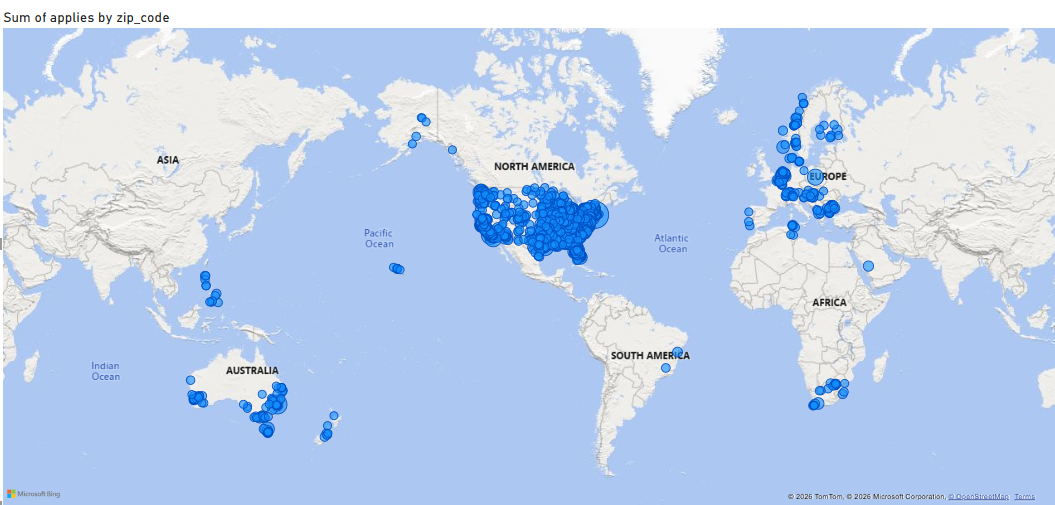

In [98]:
import numpy as np

# Step 1: Refine Location Transformation Logic

# Initialize 'location_transformed_refined' to 'Other'
df_merged['location_transformed_refined'] = 'Other'

# Update to 'USA' where 'fips' is not blank (existing logic)
df_merged.loc[df_merged['fips'].notna(), 'location_transformed_refined'] = 'USA'

# Define a comprehensive list of US states and territories (full names and abbreviations)
us_states_territories = [
    'Alabama', 'AL', 'Alaska', 'AK', 'Arizona', 'AZ', 'Arkansas', 'AR',
    'California', 'CA', 'Colorado', 'CO', 'Connecticut', 'CT', 'Delaware', 'DE',
    'Florida', 'FL', 'Georgia', 'GA', 'Hawaii', 'HI', 'Idaho', 'ID',
    'Illinois', 'IL', 'Indiana', 'IN', 'Iowa', 'IA', 'Kansas', 'KS',
    'Kentucky', 'KY', 'Louisiana', 'LA', 'Maine', 'ME', 'Maryland', 'MD',
    'Massachusetts', 'MA', 'Michigan', 'MI', 'Minnesota', 'MN', 'Mississippi', 'MS',
    'Missouri', 'MO', 'Montana', 'MT', 'Nebraska', 'NE', 'Nevada', 'NV',
    'New Hampshire', 'NH', 'New Jersey', 'NJ', 'New Mexico', 'NM', 'New York', 'NY',
    'North Carolina', 'NC', 'North Dakota', 'ND', 'Ohio', 'OH', 'Oklahoma', 'OK',
    'Oregon', 'OR', 'Pennsylvania', 'PA', 'Rhode Island', 'RI', 'South Carolina', 'SC',
    'South Dakota', 'SD', 'Tennessee', 'TN', 'Texas', 'TX', 'Utah', 'UT',
    'Vermont', 'VT', 'Virginia', 'VA', 'Washington', 'WA', 'West Virginia', 'WV',
    'Wisconsin', 'WI', 'Wyoming', 'WY',
    'District of Columbia', 'DC', 'American Samoa', 'AS', 'Guam', 'GU',
    'Northern Mariana Islands', 'MP', 'Puerto Rico', 'PR', 'U.S. Virgin Islands', 'VI'
]

# Convert to lowercase for case-insensitive matching
us_states_territories_lower = [s.lower() for s in us_states_territories]

# Analyze 'location' string for remaining 'Other' entries
for index, row in df_merged[df_merged['location_transformed_refined'] == 'Other'].iterrows():
    location_str = str(row['location']).lower()
    if any(state in location_str for state in us_states_territories_lower):
        df_merged.loc[index, 'location_transformed_refined'] = 'USA'

# Step 2: Update Location-based Metrics using the new 'location_transformed_refined' column
df_location_metrics = df_merged.groupby('location_transformed_refined').agg(
    distinct_company_ids=('company_id', 'nunique'),
    distinct_job_titles=('title', 'nunique'),
    total_applies=('applies', 'sum'),
    total_views=('views', 'sum')
).reset_index()

# Step 3: Display Refined Location Metrics
# Format numerical columns for readability
for col in ['distinct_company_ids', 'distinct_job_titles', 'total_applies', 'total_views']:
    df_location_metrics[col] = df_location_metrics[col].astype(int).apply(lambda x: f"{x:,}")

print("Refined Location-based Metrics:")
display(df_location_metrics.head())

Refined Location-based Metrics:


,location_transformed_refined,distinct_company_ids,distinct_job_titles,total_applies,total_views
0,Other,"4,057","6,516","129,344","648,013"
1,USA,"22,071","66,691","204,683","1,770,630"


## **Dataset 1** Filter Data for 2024 & USA


In [99]:
df_2024_usa = df_merged[(df_merged['year'] == 2024) & (df_merged['location_transformed_refined'] == 'USA')]
print("First 5 rows of df_2024_usa (job postings from 2024 in USA):")
#display(df_2024_usa.head())

First 5 rows of df_2024_usa (job postings from 2024 in USA):


## **Dataset 2** Filter Data for 2024 & Other

In [100]:
df_2024_other = df_merged[(df_merged['year'] == 2024) & (df_merged['location_transformed_refined'] == 'Other')]
print("First 5 rows of df_2024_other (job postings from 2024 outside USA):")
#display(df_2024_other.head())

First 5 rows of df_2024_other (job postings from 2024 outside USA):


## **Dataset 3** Filter Data for 2024 (All)

In [101]:
df_2024_all = df_merged[df_merged['year'] == 2024].copy()
print("First 5 rows of df_2024_all (job postings from 2024 overall):")
display(df_2024_all.head())
print("Rows:", len(df_2024_all), " | Unique jobs:", df_2024_all['job_id'].nunique())

First 5 rows of df_2024_all (job postings from 2024 overall):


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,work_type,currency,compensation_type,normalized_salary,zip_code,fips,industry_id,industry_name,year,location_transformed_refined
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0,44.0,Real Estate,2024,USA
1,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0,32.0,Restaurants,2024,USA
2,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0,9.0,Law Practice,2024,USA
3,91700727,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20.0,HOURLY,"Raleigh, NC",1481176.0,9.0,NaN,...,INTERNSHIP,USD,BASE_SALARY,35360.0,27601.0,37183.0,3202.0,Non-profit Organization Management,2024,USA
4,103254301,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,300000.0,YEARLY,United States,81942316.0,7.0,NaN,...,CONTRACT,USD,BASE_SALARY,180000.0,NaN,NaN,99.0,Design Services,2024,Other


Rows: 158447  | Unique jobs: 122130


In [102]:
df_2024_usa_industry_metrics = df_2024_usa.groupby('industry_name')[['applies', 'views']].sum().reset_index()

df_2024_other_industry_metrics = df_2024_other.groupby('industry_name')[['applies', 'views']].sum().reset_index()

df_2024_all = df_merged[df_merged['year'] == 2024].copy()

In [103]:
import pandas as pd

def process_plot_data(df, metric_col='applies', top_n=10, threshold_pct=0.01):
    """
    ฟังก์ชันสำหรับกรองข้อมูล, เรียงลำดับ และคัดเลือก Top N สำหรับวาดกราฟ
    """
    # 1. เลือกเฉพาะแถวที่ applies > 0 และเรียงลำดับจากมากไปน้อย
    df_plot = df[df[metric_col] > 0].sort_values(by=metric_col, ascending=False)

    # 2. ตรวจสอบเงื่อนไขตาม Logic เดิมที่สรุปให้สั้นลง
    if len(df_plot) > top_n:
        # ถ้ามีอุตสาหกรรมมากกว่า 10 อัน ให้ตัดมาแค่ Top 10 พอ
        return df_plot.head(top_n)
    else:
        # ถ้ามีไม่เกิน 10 อัน ให้กรองเอาเฉพาะอันที่สัดส่วนเกิน 1% ของทั้งหมด
        total_applies = df_plot[metric_col].sum()
        return df_plot[df_plot[metric_col] / total_applies > threshold_pct]

# --- ใช้งานฟังก์ชันกับทั้ง 2 Dataframe ---
df_applies_plot_final_usa = process_plot_data(df_2024_usa_industry_metrics)
df_applies_plot_final_other = process_plot_data(df_2024_other_industry_metrics)

# --- รวมรายชื่อ Industry ที่ไม่ซ้ำกันทั้งหมด ---
all_unique_industries = pd.concat([
    df_applies_plot_final_usa['industry_name'],
    df_applies_plot_final_other['industry_name']
]).unique()


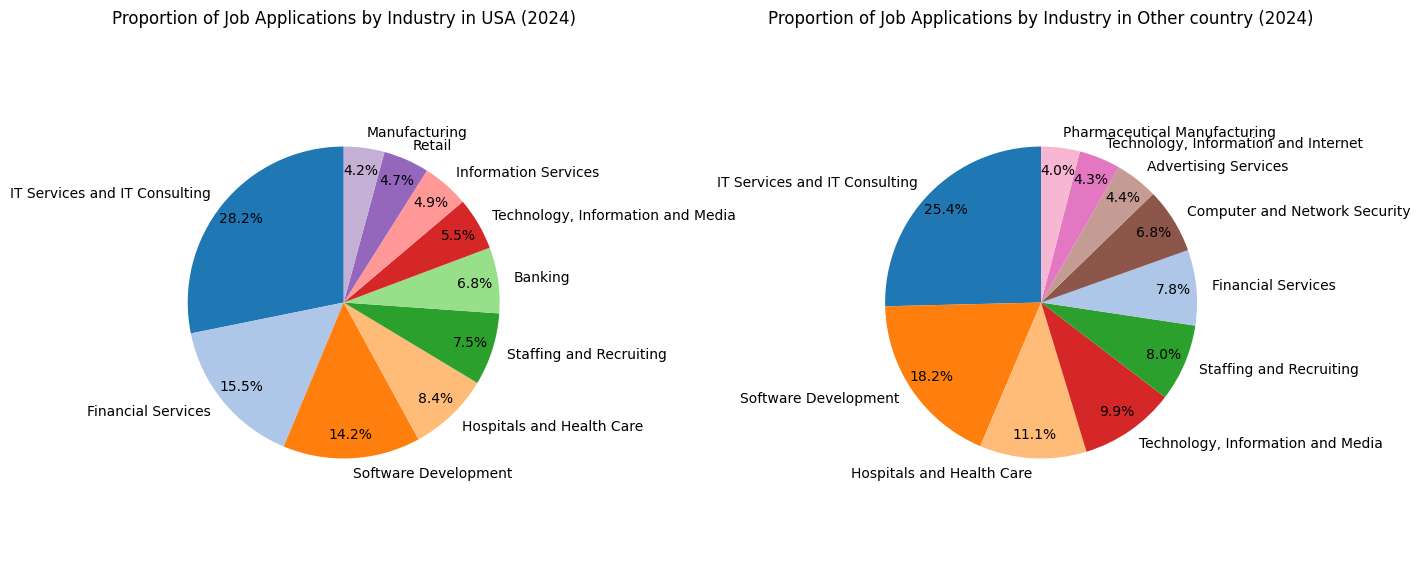

In [104]:
import matplotlib.pyplot as plt
# Create a color map for all unique industries
cmap = plt.colormaps.get_cmap('tab20')
# ป้องกัน Error กรณีมี Industry เกิน 20 อัน ด้วยการใช้ i % 20
color_map_dict = {industry: cmap(i % 20) for i, industry in enumerate(all_unique_industries)}

# --- 1. แก้ไขเรื่องสี ---
# สร้างลิสต์สีแยกสำหรับแต่ละกราฟ ให้ตรงกับข้อมูลใน Dataframe ของตัวเอง
colors_usa = [color_map_dict[industry] for industry in df_applies_plot_final_usa['industry_name']]
colors_other = [color_map_dict[industry] for industry in df_applies_plot_final_other['industry_name']]

# --- 2. แก้ไขเรื่องการจัดวาง (ซ้าย-ขวา) ---
# สร้าง Figure ที่มี 1 แถว 2 คอลัมน์ (ปรับขนาด figsize ให้กว้างขึ้นเพื่อรองรับ 2 กราฟ)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- วาดกราฟที่ 1 (ซ้าย: USA) ลงใน ax1 ---
ax1.pie(df_applies_plot_final_usa['applies'],
        labels=df_applies_plot_final_usa['industry_name'],
        autopct='%1.1f%%', startangle=90, pctdistance=0.85,
        colors=colors_usa)
ax1.set_title('Proportion of Job Applications by Industry in USA (2024)')
ax1.axis('equal')

# --- วาดกราฟที่ 2 (ขวา: Other) ลงใน ax2 ---
# สังเกตว่าเปลี่ยนมาใช้ colors=colors_other แล้ว
ax2.pie(df_applies_plot_final_other['applies'],
        labels=df_applies_plot_final_other['industry_name'],
        autopct='%1.1f%%', startangle=90, pctdistance=0.85,
        colors=colors_other)
ax2.set_title('Proportion of Job Applications by Industry in Other country (2024)')
ax2.axis('equal')

# คำสั่งนี้ช่วยจัดช่องไฟระหว่าง 2 กราฟไม่ให้ตัวหนังสือทับกัน
plt.tight_layout()
plt.show()

วงกลม อยากจะบอกว่ามันมันสะท้อน พฤติกรรมคนสมัครงาน ของในประเทศ และ นอกประเทศ assum ว่ามีการสมัคร ทั้ง2แบบ แปลว่าธุรกิจนี้ need คนเข้ามาสมัครเยอะ ตามเทรนด์ และ Worldwide ไหม

In [105]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## **Remote Trend Over Time**
Analyze the trend of remote jobs by month/quarter and compare USA vs Other.

,month,total_posts,remote_posts,remote_share
0,2024-01-01,6,2,0.333333
1,2024-02-01,8,2,0.250000
2,2024-03-01,1811,287,0.158476
3,2024-04-01,120305,20116,0.167208


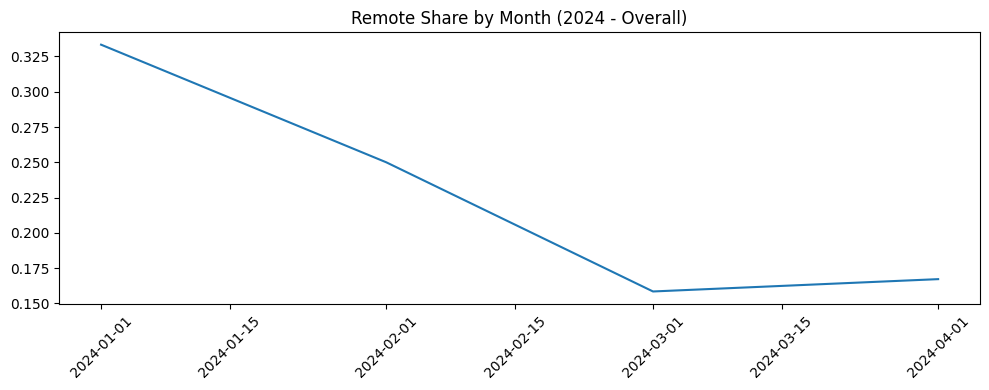

,quarter,total_posts,remote_posts,remote_share
0,2024Q1,1825,291,0.159452
1,2024Q2,120305,20116,0.167208


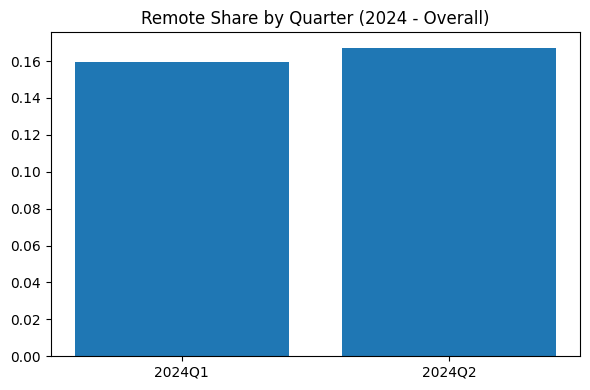

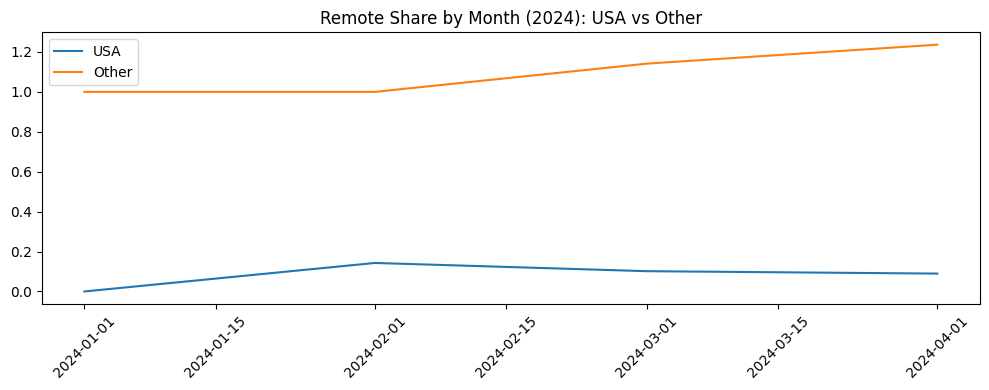

In [106]:
# ===== 5.4 Remote Trend Over Time (2024) =====

# 1) เตรียมคอลัมน์ที่จำเป็น (ใช้ของเดิมเป็นหลัก)
df_2024_all = df_2024_all.copy()

# กันพัง: ถ้า original_listed_time ยังไม่เป็น datetime ให้แปลง (ส่วนใหญ่คุณทำแล้ว)
if not np.issubdtype(df_2024_all['original_listed_time'].dtype, np.datetime64):
    df_2024_all['original_listed_time'] = pd.to_datetime(df_2024_all['original_listed_time'])

# remote_allowed ให้เป็น 0/1
df_2024_all['remote_allowed'] = df_2024_all['remote_allowed'].fillna(0).astype(int)

# สร้าง month/quarter
df_2024_all['month'] = df_2024_all['original_listed_time'].dt.to_period('M').dt.to_timestamp()
df_2024_all['quarter'] = df_2024_all['original_listed_time'].dt.to_period('Q').astype(str)

# 2) Remote share รายเดือน (ทั้งตลาด 2024)
remote_month = df_2024_all.groupby('month').agg(
    total_posts=('job_id', 'nunique'),
    remote_posts=('remote_allowed', 'sum')
).reset_index()

remote_month['remote_share'] = remote_month['remote_posts'] / remote_month['total_posts']
display(remote_month)

plt.figure(figsize=(10,4))
plt.plot(remote_month['month'], remote_month['remote_share'])
plt.title('Remote Share by Month (2024 - Overall)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3) Remote share รายไตรมาส
remote_quarter = df_2024_all.groupby('quarter').agg(
    total_posts=('job_id', 'nunique'),
    remote_posts=('remote_allowed', 'sum')
).reset_index()
remote_quarter['remote_share'] = remote_quarter['remote_posts'] / remote_quarter['total_posts']
display(remote_quarter)

plt.figure(figsize=(6,4))
plt.bar(remote_quarter['quarter'], remote_quarter['remote_share'])
plt.title('Remote Share by Quarter (2024 - Overall)')
plt.tight_layout()
plt.show()

# 4) เปรียบเทียบ USA vs Other (remote_share)
remote_geo_month = df_2024_all.groupby(['location_transformed_refined','month']).agg(
    total_posts=('job_id','nunique'),
    remote_posts=('remote_allowed','sum')
).reset_index()
remote_geo_month['remote_share'] = remote_geo_month['remote_posts'] / remote_geo_month['total_posts']

usa_line = remote_geo_month[remote_geo_month['location_transformed_refined']=='USA']
oth_line = remote_geo_month[remote_geo_month['location_transformed_refined']=='Other']

plt.figure(figsize=(10,4))
plt.plot(usa_line['month'], usa_line['remote_share'], label='USA')
plt.plot(oth_line['month'], oth_line['remote_share'], label='Other')
plt.title('Remote Share by Month (2024): USA vs Other')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## **Salary Comparison: Remote vs Non-Remote**
Compare normalized salary between remote and non-remote jobs, and split by USA vs Other.

,total_unique_jobs_2024,jobs_with_salary,salary_coverage_%
0,122130,35550,29.108327


,remote_allowed,n,median,mean,remote_label
0,0,41176,80000.0,181760.927624,Non-Remote
1,1,6708,115000.0,210554.436747,Remote


,location_transformed_refined,remote_allowed,n,median,mean,remote_label
0,Other,0,162,87500.0,102266.344321,Non-Remote
1,Other,1,3493,119000.0,127626.386940,Remote
2,USA,0,41014,80000.0,182074.920956,Non-Remote
3,USA,1,3215,113487.5,300653.247938,Remote


/tmp/ipython-input-2497763463.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Remote','Non-Remote'], showfliers=False)


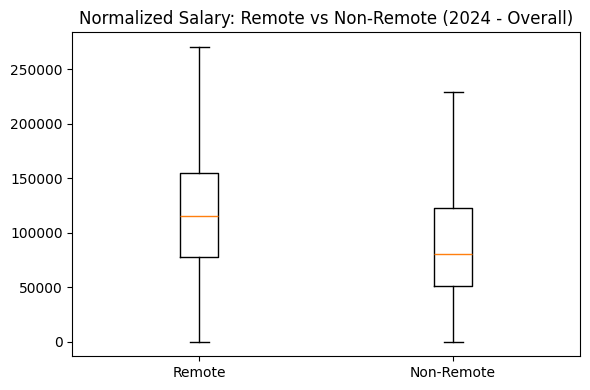

/tmp/ipython-input-2497763463.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=order, showfliers=False)


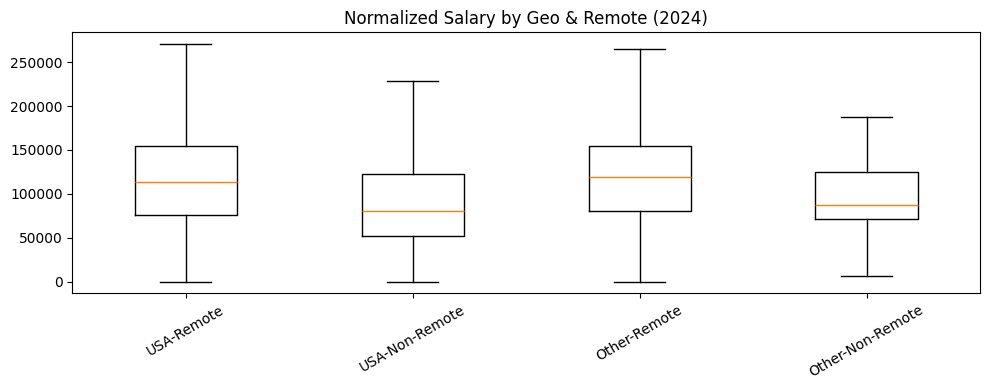

In [107]:
# ===== 5.5 Salary Comparison (2024) =====

# 1) เตรียมข้อมูลเงินเดือน
salary_df = df_2024_all[df_2024_all['normalized_salary'].notna()].copy()
salary_df = salary_df[salary_df['normalized_salary'] > 0]

# Coverage ว่ามี salary กี่โพสต์
coverage = pd.DataFrame({
    'total_unique_jobs_2024': [df_2024_all['job_id'].nunique()],
    'jobs_with_salary': [salary_df['job_id'].nunique()]
})
coverage['salary_coverage_%'] = coverage['jobs_with_salary'] / coverage['total_unique_jobs_2024'] * 100
display(coverage)

# 2) สรุป Remote vs Non-Remote (overall)
summary_remote = salary_df.groupby('remote_allowed')['normalized_salary'].agg(
    n='count',
    median='median',
    mean='mean'
).reset_index()

summary_remote['remote_label'] = summary_remote['remote_allowed'].map({1:'Remote',0:'Non-Remote'})
display(summary_remote)

# 3) สรุปแยก USA vs Other
summary_geo = salary_df.groupby(['location_transformed_refined','remote_allowed'])['normalized_salary'].agg(
    n='count',
    median='median',
    mean='mean'
).reset_index()
summary_geo['remote_label'] = summary_geo['remote_allowed'].map({1:'Remote',0:'Non-Remote'})
display(summary_geo)

# 4) Boxplot (ตัด outlier เพื่อให้อ่านง่าย)
data = [
    salary_df[salary_df['remote_allowed']==1]['normalized_salary'],
    salary_df[salary_df['remote_allowed']==0]['normalized_salary']
]
plt.figure(figsize=(6,4))
plt.boxplot(data, labels=['Remote','Non-Remote'], showfliers=False)
plt.title('Normalized Salary: Remote vs Non-Remote (2024 - Overall)')
plt.tight_layout()
plt.show()

# 5) Boxplot แยก 4 กลุ่ม: USA/Other x Remote/Non
salary_df['group'] = salary_df['location_transformed_refined'] + "-" + salary_df['remote_allowed'].map({1:'Remote',0:'Non-Remote'})
order = ['USA-Remote','USA-Non-Remote','Other-Remote','Other-Non-Remote']
plot_data = [salary_df[salary_df['group']==g]['normalized_salary'] for g in order]

plt.figure(figsize=(10,4))
plt.boxplot(plot_data, labels=order, showfliers=False)
plt.title('Normalized Salary by Geo & Remote (2024)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## **Skills Analysis**
(1) Top demanded skills, (2) High-paying skills, and (3) High-paying skills in Remote jobs.

,skill_name,count
0,Information Technology,31535
1,Sales,28102
2,Management,25544
3,Manufacturing,21524
4,Health Care Provider,19127
5,Engineering,17728
6,Business Development,17576
7,Other,15869
8,Finance,11527
9,Marketing,8091


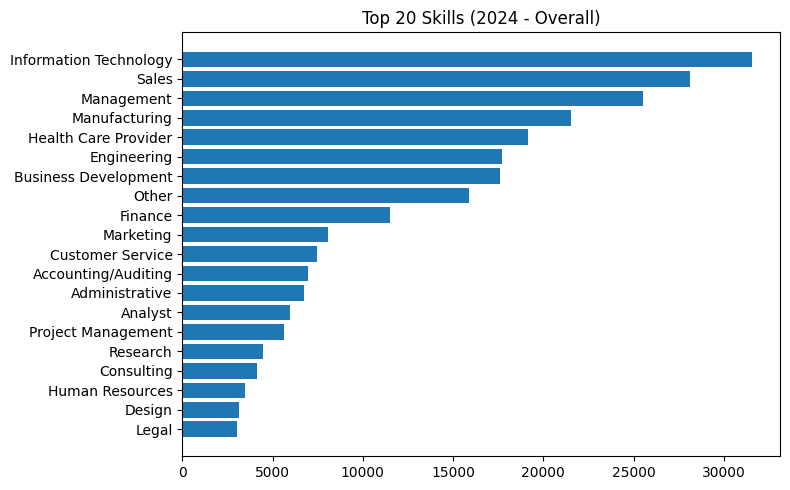

,skill_name,n,median,mean
22,Product Management,692,137500.0,142375.899487
31,Strategy/Planning,895,125000.0,133885.865922
17,Legal,1439,122500.0,776237.234017
11,Engineering,5610,122500.0,259168.382457
16,Information Technology,9427,115000.0,257372.696861
24,Project Management,2225,115000.0,120058.067998
6,Consulting,1447,114379.2,127131.580097
8,Design,1149,100880.0,106536.542476
28,Research,1399,95555.2,118049.267884
30,Science,676,95513.6,118164.992500


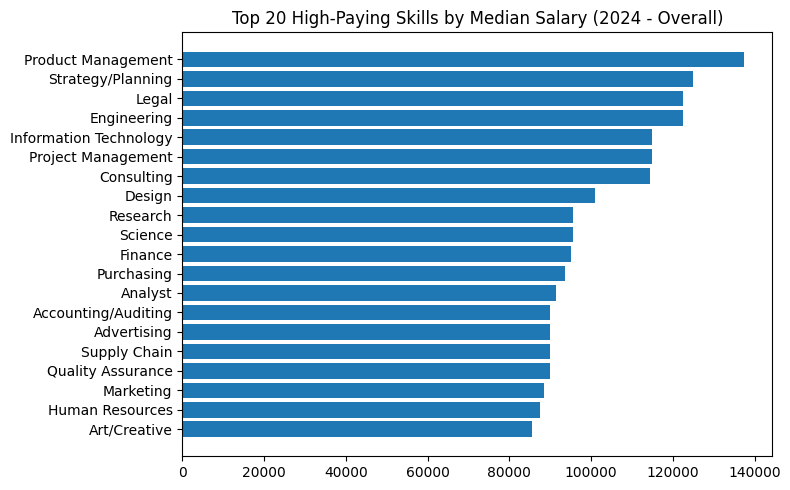

,skill_name,n,median,mean
30,Science,87,145600.0,164238.073563
11,Engineering,879,145000.0,152682.876684
31,Strategy/Planning,123,140400.0,154451.520325
17,Legal,198,140000.0,161314.828788
32,Supply Chain,51,135000.0,132685.500000
6,Consulting,389,135000.0,156163.179692
16,Information Technology,1978,130000.0,424920.631684
22,Product Management,170,129125.0,139552.817647
28,Research,187,125000.0,139694.945241
8,Design,167,124800.0,119851.474461


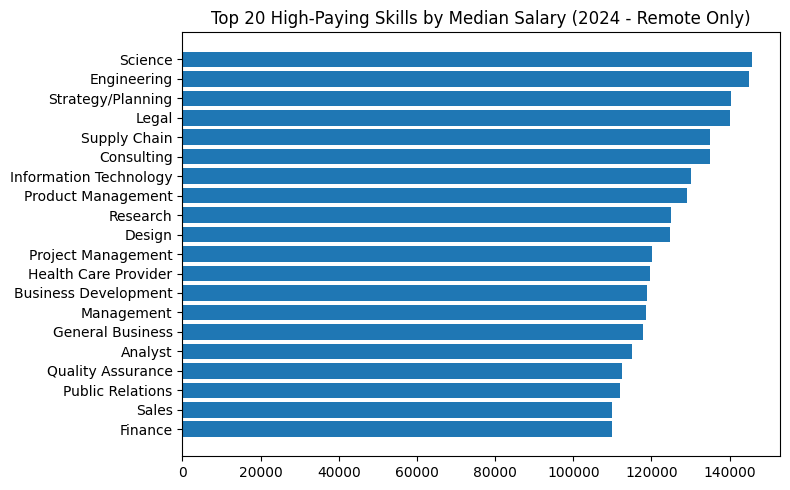

In [108]:
# ===== 5.6 Skills Analysis (2024) =====

# 1) ทำตาราง skill_name ให้พร้อม (job_skills + skills mapping)
job_skills_named = df_job_skills.merge(df_skills, on='skill_abr', how='left')
job_skills_named = job_skills_named[job_skills_named['skill_name'].notna()].copy()

# 2) join เข้ากับโพสต์ปี 2024
skills_2024 = df_2024_all[['job_id','remote_allowed','location_transformed_refined','normalized_salary']].merge(
    job_skills_named[['job_id','skill_name']],
    on='job_id',
    how='inner'
)

# A) Top skills (Demand)
top_skills = (skills_2024['skill_name']
              .value_counts()
              .head(20)
              .reset_index())
top_skills.columns = ['skill_name','count']
display(top_skills)

plt.figure(figsize=(8,5))
plt.barh(top_skills['skill_name'][::-1], top_skills['count'][::-1])
plt.title('Top 20 Skills (2024 - Overall)')
plt.tight_layout()
plt.show()

# B) High-paying skills (ใช้ median salary ต่อ skill)
# เงื่อนไขกัน noise: ต้องมี salary และจำนวนขั้นต่ำ
skill_salary = skills_2024.dropna(subset=['normalized_salary']).copy()
skill_salary = skill_salary[skill_salary['normalized_salary'] > 0]

skill_stats = (skill_salary.groupby('skill_name')['normalized_salary']
               .agg(n='count', median='median', mean='mean')
               .reset_index())

# ตั้ง threshold จำนวนขั้นต่ำ (ปรับได้)
skill_stats_filtered = skill_stats[skill_stats['n'] >= 50].sort_values('median', ascending=False).head(20)
display(skill_stats_filtered)

plt.figure(figsize=(8,5))
plt.barh(skill_stats_filtered['skill_name'][::-1], skill_stats_filtered['median'][::-1])
plt.title('Top 20 High-Paying Skills by Median Salary (2024 - Overall)')
plt.tight_layout()
plt.show()

# C) High-paying skills (Remote only)
remote_skill_salary = skill_salary[skill_salary['remote_allowed'] == 1].copy()

remote_skill_stats = (remote_skill_salary.groupby('skill_name')['normalized_salary']
                      .agg(n='count', median='median', mean='mean')
                      .reset_index())

remote_skill_stats_filtered = remote_skill_stats[remote_skill_stats['n'] >= 30].sort_values('median', ascending=False).head(20)
display(remote_skill_stats_filtered)

plt.figure(figsize=(8,5))
plt.barh(remote_skill_stats_filtered['skill_name'][::-1], remote_skill_stats_filtered['median'][::-1])
plt.title('Top 20 High-Paying Skills by Median Salary (2024 - Remote Only)')
plt.tight_layout()
plt.show()